# IMPORTS

In [19]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import librosa
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, f1_score
import soundfile as sf
from PIL import Image
from pydub import AudioSegment
from pydub.utils import which
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torchaudio.transforms as T
import cv2
from sklearn.model_selection import GroupShuffleSplit
from tqdm import tqdm

# DATASET

## CREMA-D

### Load CREMA-D

In [2]:
dataset_folder = "dataset\\CREMA-D\\AudioWAV\\"

data = []

emotion_map = {
    "ANG": "Anger",
    "DIS": "Disgust",
    "FEA": "Fear",
    "HAP": "Happy",
    "NEU": "Neutral",
    "SAD": "Sad",
}


for file in os.listdir(dataset_folder):
    filename, _ = os.path.splitext(file)

    parts = filename.split("_")

    # Speaker
    speaker = parts[0]

    # Path
    path = os.path.join(dataset_folder, file)

    # Emotion
    emotion_code = parts[2]
    emotion = emotion_map.get(emotion_code, "Unknown")

    data.append([speaker, path, emotion])

dataset_df = pd.DataFrame(data, columns=["speaker", "path", "emotion"])
print(dataset_df.shape[0])

7442


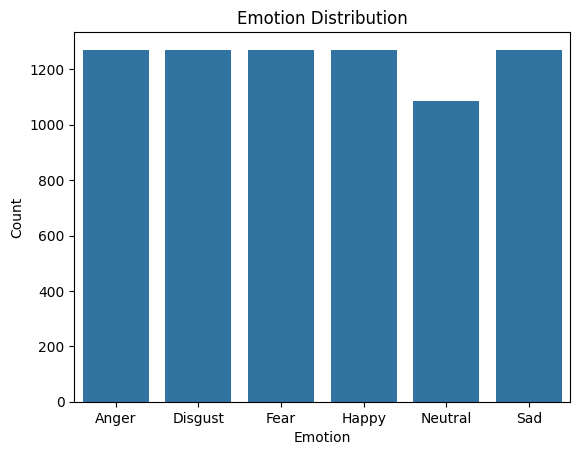

In [3]:
sns.countplot(x="emotion", data=dataset_df)
plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

In [4]:
def create_csv(df: pd.DataFrame, output_csv: str):
    df.to_csv(output_csv, index=False)

os.makedirs("CSVs", exist_ok=True)
    
create_csv(dataset_df, "CSVs\\dataset.csv")

### Remove silence

In [ ]:
AudioSegment.converter = which("ffmpeg")

location = "dataset_silenced\\"
os.makedirs(location, exist_ok=True)


def detect_leading_silence(dls_audio):
    dls_chunk_size = 10
    dls_silence_threshold = -50.0

    trim_ms = 0
    dls_audio_length = len(dls_audio)

    while trim_ms < dls_audio_length:
        chunk_dBFS = dls_audio[trim_ms : trim_ms + dls_chunk_size].dBFS
        if chunk_dBFS > dls_silence_threshold:
            break
        trim_ms += dls_chunk_size

    return trim_ms


name = 0
errors = 0
file_data = []

# Process each audio file, remove leading and trailing silence, and save the new audio files
for _, row in dataset_df.iterrows():
    file_name = f"{location}{name}.wav"

    try:
        audio = AudioSegment.from_file(row["path"], format="wav")
    except:  # noqa: E722
        audio = AudioSegment.from_file(row["path"])

    start_trim = detect_leading_silence(audio)
    end_trim = detect_leading_silence(audio.reverse())

    duration = len(audio)
    new_audio = audio[start_trim : duration - end_trim]

    if len(new_audio) > 0:
        os.makedirs(os.path.dirname(file_name), exist_ok=True)
        new_audio.export(file_name, format="wav")
    else:
        audio.export(file_name, format="wav")
        errors += 1
        print(f"Audio too short: {row['path']}, saved original audio.")

    file_data.append([row["speaker"], file_name, row["emotion"]])
    name += 1

dataset_silenced = pd.DataFrame(file_data, columns=["speaker", "path", "emotion"])
create_csv(dataset_silenced, "CSVs\\dataset_silenced.csv")

### Split dataset

In [5]:
gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_idx, temp_idx = next(gss.split(dataset_df, groups=dataset_df["speaker"]))

gss = GroupShuffleSplit(test_size=0.5, n_splits=1, random_state=42)
val_idx, test_idx = next(
    gss.split(
        dataset_df.loc[temp_idx], groups=dataset_df.loc[temp_idx]["speaker"]
    )
)

train_df = dataset_df.iloc[train_idx].reset_index(drop=True)
val_df = dataset_df.iloc[temp_idx].iloc[val_idx].reset_index(drop=True)
test_df = dataset_df.iloc[temp_idx].iloc[test_idx].reset_index(drop=True)

print(f"Train set: {len(train_df)} samples")
print(f"Validation set: {len(val_df)} samples")
print(f"Test set: {len(test_df)} samples")

create_csv(train_df, "CSVs\\train.csv")
create_csv(val_df, "CSVs\\val.csv")
create_csv(test_df, "CSVs\\test.csv")

Train set: 5890 samples
Validation set: 732 samples
Test set: 820 samples


### Data augmentation

In [ ]:
import random

location = "dataset_augmented\\"
os.makedirs(location, exist_ok=True)


def noise(n_data):
    noise_amp = 0.005 * np.random.uniform() * np.max(np.abs(n_data))
    return n_data + noise_amp * np.random.normal(size=n_data.shape[0])


def stretch(s_data):
    s_rate = np.random.uniform(0.95, 1.05)
    return librosa.effects.time_stretch(s_data, rate=s_rate)


def pitch(p_data, p_sampling_rate):
    p_pitch_factor = np.random.uniform(-1, 1)
    return librosa.effects.pitch_shift(
        p_data, sr=p_sampling_rate, n_steps=p_pitch_factor
    )


name = 0
file_data = []

# Process each audio file, apply random augmentation, and save the new audio files
for _, row in train_df.iterrows():
    data, sampling_rate = librosa.load(row["path"], sr=None)

    # Original audio
    file_name = f"{location}{name}.wav"
    sf.write(file_name, data, sampling_rate)

    file_data.append([row["speaker"], file_name, row["emotion"]])
    name += 1

    # Randomly select an augmentation type
    aug_type = random.choices(
        ["noise", "stretch", "pitch"], weights=[0.4, 0.3, 0.3], k=1
    )[0]

    augment_map = {
        "noise": lambda: noise(data),
        "stretch": lambda: stretch(data),
        "pitch": lambda: pitch(data, sampling_rate),
    }

    aug_data = augment_map[aug_type]()

    file_name = f"{location}{name}.wav"
    sf.write(file_name, aug_data, sampling_rate)

    file_data.append([row["speaker"], file_name, row["emotion"]])
    name += 1

    print(f"Processed {name} files", end="\r", flush=True)


train_df_augmented = pd.DataFrame(file_data, columns=["speaker", "path", "emotion"])
create_csv(train_df_augmented, "CSVs\\dataset_augmented.csv")

# CONVERT TO MEL SPECTROGRAM

## Run

In [9]:
from scipy.io import wavfile

location = "features/images/"
os.makedirs(location, exist_ok=True)

IMG_SIZE = 224


def graph_spectrogram(gs_audio, gs_file_name):
    rate, data = wavfile.read(gs_audio)
    
    # Add a small epsilon to avoid log(0)
    data = data.astype(float) + 1e-9

    fig, ax = plt.subplots(1)
    fig.set_size_inches(IMG_SIZE / 100, IMG_SIZE / 100)
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
    ax.axis("off")

    ax.specgram(x=data, Fs=rate, cmap="viridis", noverlap=384, NFFT=512)

    fig.savefig(gs_file_name, dpi=100)
    plt.close(fig=fig)


def prepare_images(pi_df, pi_Name):
    data = []
    labels = []

    # Process each audio file, generate spectrogram images, and store them in the data and labels lists
    for idx, row in tqdm(
        pi_df.iterrows(), total=len(pi_df), desc=f"Processing {pi_Name}"
    ):
        file_name = f"{location}{pi_Name}_{idx}.png"
        graph_spectrogram(row["path"], file_name)

        # Read RGB image instead of grayscale
        image = cv2.imread(file_name, cv2.IMREAD_COLOR)

        if image is None:
            print(f"Error loading image: {row['path']}")
            continue

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        data.append(image)
        labels.append(row["emotion"])

    data = np.array(data, dtype="float") / 255.0
    labels = np.array(labels)

    np.save(f"features/{pi_Name}_images_data.npy", data)
    np.save(f"features/{pi_Name}_images_labels.npy", labels)
    print(f"Saved {len(data)} images and labels for {pi_Name}.")


data_path_Train = pd.read_csv("CSVs/train.csv")
data_path_Val = pd.read_csv("CSVs/val.csv")
data_path_Test = pd.read_csv("CSVs/test.csv")

prepare_images(data_path_Train, "train")
prepare_images(data_path_Val, "val")
prepare_images(data_path_Test, "test")

Processing train:  22%|██▏       | 1281/5890 [00:57<03:13, 23.85it/s]d:\Coding\Projects\private_PRJ\speech-emotion-recognition-ravdess\.venv\Lib\site-packages\matplotlib\axes\_axes.py:8283: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)
Processing train: 100%|██████████| 5890/5890 [05:29<00:00, 17.86it/s]


Saved 5890 images and labels for train.


Processing val: 100%|██████████| 732/732 [00:51<00:00, 14.15it/s]


Saved 732 images and labels for val.


Processing test: 100%|██████████| 820/820 [00:58<00:00, 13.90it/s]


Saved 820 images and labels for test.


# DATA PREPROCESSING

## Config

In [5]:
location = "features\\"
csv_dir = "CSVs\\"
train_df = pd.read_csv(os.path.join(csv_dir, "train.csv"))
val_df = pd.read_csv(os.path.join(csv_dir, "val.csv"))
test_df = pd.read_csv(os.path.join(csv_dir, "test.csv"))

MIN_SAMPLES = 2048
TARGET_DURATION = 3.0  # seconds
IMG_SIZE = 224

# Mel params 
# Đây là số lượng dải Mel sẽ được sử dụng để tạo ra spectrogram. 
# Số lượng này ảnh hưởng đến độ phân giải của spectrogram và 
# khả năng mô hình học được các đặc trưng quan trọng từ dữ liệu âm thanh.
N_MELS = 128

# Đây là kích thước của cửa sổ FFT được sử dụng để tính toán spectrogram.
# Kích thước này ảnh hưởng đến độ phân giải tần số của spectrogram và
# khả năng mô hình học được các đặc trưng tần số quan trọng từ dữ liệu âm thanh.
N_FFT = 1024  

# Đây là khoảng cách giữa các cửa sổ FFT liên tiếp khi tính toán spectrogram.
# Khoảng cách này ảnh hưởng đến độ phân giải thời gian của spectrogram và
# khả năng mô hình học được các đặc trưng thời gian quan trọng từ dữ liệu âm thanh.
HOP_LENGTH = 256  

## Unload processed spetrogram images

In [6]:
x_trainI = np.load('features\\train_images_data.npy')
x_validationI = np.load('features\\val_images_data.npy')
x_testI = np.load('features\\test_images_data.npy')

Labels_train_I = np.load('features\\train_images_labels.npy')
Labels_val_I = np.load('features\\val_images_labels.npy')
Labels_test_I = np.load('features\\test_images_labels.npy')

# One-hot encoding

encoder = OneHotEncoder(sparse_output=False)
y_trainI = encoder.fit_transform(np.array(Labels_train_I).reshape(-1, 1))
y_validationI = encoder.transform(np.array(Labels_val_I).reshape(-1, 1))
y_testI = encoder.transform(np.array(Labels_test_I).reshape(-1, 1))

print(x_trainI.shape)
print(x_validationI.shape)
print(x_testI.shape)
print(y_trainI.shape)
print(y_validationI.shape)
print(y_testI.shape)

(5890, 224, 224, 3)
(732, 224, 224, 3)
(820, 224, 224, 3)
(5890, 6)
(732, 6)
(820, 6)


## Data loader

In [12]:
# Create a mapping from emotion labels to integers
emotion_list = sorted(dataset_df["emotion"].unique())
emotion_to_int = {emotion: i for i, emotion in enumerate(emotion_list)}
int_to_emotion = {i: emotion for emotion, i in emotion_to_int.items()}


# Custom Dataset
class EmotionDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        # Convert numpy array to PIL Image
        # The image is already in range [0, 1], so we multiply by 255
        image = Image.fromarray((image * 255).astype(np.uint8))

        if self.transform:
            image = self.transform(image)

        # Convert one-hot encoded label to class index
        label = torch.tensor(np.argmax(label)).long()

        return image, label


In [13]:

IMG_SIZE = 224
data_transforms = {
    "train": transforms.Compose(
        [
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            T.TimeMasking(time_mask_param=80),
            T.FrequencyMasking(freq_mask_param=80),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
        ]
    ),
    "val": transforms.Compose(
        [
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
        ]
    ),
    "test": transforms.Compose(
        [
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
        ]
    ),
}

# Create Datasets
train_dataset = EmotionDataset(x_trainI, y_trainI, transform=data_transforms["train"])
val_dataset = EmotionDataset(x_validationI, y_validationI, transform=data_transforms["val"])
test_dataset = EmotionDataset(x_testI, y_testI, transform=data_transforms["test"])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

dataloaders = {"train": train_loader, "val": val_loader, "test": test_loader}
dataset_sizes = {
    "train": len(train_dataset),
    "val": len(val_dataset),
    "test": len(test_dataset),
}

print(f"Train loader size: {len(train_loader)}")
print(f"Validation loader size: {len(val_loader)}")
print(f"Test loader size: {len(test_loader)}")


Train loader size: 185
Validation loader size: 23
Test loader size: 26


# MODEL

## Setup

In [27]:
class build_model(nn.Module):
    def __init__(self, num_classes):
        super(build_model, self).__init__()

        self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # Unfreeze some layers
        for param in self.model.parameters():
            param.requires_grad = False

        for layer in [self.model.layer4]:
            for param in layer.parameters():
                param.requires_grad = True

        # Modify the fully connected layer
        self.model.fc = nn.Sequential( # type: ignore
            nn.Linear(self.model.fc.in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.model(x)


# Build model, define loss function, optimizer, and learning rate scheduler
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = build_model(num_classes=6).to(device)

criterion = nn.CrossEntropyLoss()
# Lower learning rate for more stable convergence
optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=5e-4) 
# Adjust scheduler patience
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5 
)


Using device: cuda:0


## Train & Validate

In [25]:
EPOCHS = 100
PATIENCE = 10 # Increased patience for ReduceLROnPlateau

best_val_loss = float("inf")
best_epoch = 0
counter = 0

# best_weights = copy.deepcopy(model.state_dict())

history = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
}

for epoch in range(EPOCHS):
    # ==========================
    # TRAIN
    # ==========================
    model.train()

    train_labels_all = []
    train_preds_all = []
    running_loss = 0
    train_total = 0

    tqdm_loader = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{EPOCHS} - Training", leave=False)
    for images, labels in tqdm_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        train_total += batch_size

        preds = torch.argmax(outputs, dim=1)
        train_labels_all.extend(labels.cpu().numpy())
        train_preds_all.extend(preds.cpu().numpy())

    train_loss = running_loss / train_total
    train_acc = accuracy_score(train_labels_all, train_preds_all)
    train_f1 = f1_score(train_labels_all, train_preds_all, average="weighted")

    # ==========================
    # VALIDATION
    # ==========================
    model.eval()
    val_labels_all = []
    val_preds_all = []
    val_running_loss = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch + 1}/{EPOCHS} - Validation", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size = images.size(0)
            val_running_loss += loss.item() * batch_size
            val_total += batch_size

            preds = torch.argmax(outputs, dim=1)
            val_labels_all.extend(labels.cpu().numpy())
            val_preds_all.extend(preds.cpu().numpy())

    val_loss = val_running_loss / val_total
    val_acc = accuracy_score(val_labels_all, val_preds_all)
    val_f1 = f1_score(val_labels_all, val_preds_all, average="weighted")

    # Step the scheduler
    scheduler.step(val_loss)

    # history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"Train | Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
    print(f"Val   | Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")
    print(f"LR: {optimizer.param_groups[0]['lr']:.2e}")


    # ==========================
    # EARLY STOPPING & SAVE BEST MODEL
    # ==========================
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
        print("--> New Best Model Saved!")
    else:
        counter += 1
        if counter >= PATIENCE:
            print("Early stopping triggered.")
            break

# ==========================
# RESTORE BEST WEIGHTS
# ==========================
model.load_state_dict(torch.load('best_model.pth'))
print(f"Best epoch: {best_epoch}")


Epoch 1/100
Train | Loss: 1.7741 | Acc: 0.2190 | F1: 0.2176
Val   | Loss: 1.6200 | Acc: 0.3825 | F1: 0.3208
LR: 1.00e-05
--> New Best Model Saved!


Epoch 2/100
Train | Loss: 1.6550 | Acc: 0.3195 | F1: 0.2819
Val   | Loss: 1.5436 | Acc: 0.3716 | F1: 0.2758
LR: 1.00e-05
--> New Best Model Saved!


Epoch 3/100
Train | Loss: 1.5679 | Acc: 0.3555 | F1: 0.3154
Val   | Loss: 1.4873 | Acc: 0.3934 | F1: 0.3180
LR: 1.00e-05
--> New Best Model Saved!


Epoch 4/100
Train | Loss: 1.5170 | Acc: 0.3764 | F1: 0.3457
Val   | Loss: 1.4285 | Acc: 0.4276 | F1: 0.3769
LR: 1.00e-05
--> New Best Model Saved!


Epoch 5/100
Train | Loss: 1.4756 | Acc: 0.3993 | F1: 0.3753
Val   | Loss: 1.3590 | Acc: 0.4686 | F1: 0.4224
LR: 1.00e-05
--> New Best Model Saved!


...

Epoch 35/100
Train | Loss: 0.9071 | Acc: 0.6559 | F1: 0.6554
Val   | Loss: 1.0343 | Acc: 0.6489 | F1: 0.6432
LR: 2.50e-06


Epoch 36/100
Train | Loss: 0.9014 | Acc: 0.6620 | F1: 0.6609
Val   | Loss: 1.0127 | Acc: 0.6516 | F1: 0.6464
LR: 2.50e-06


Epoch 37/100
Train | Loss: 0.9100 | Acc: 0.6564 | F1: 0.6548
Val   | Loss: 1.0279 | Acc: 0.6585 | F1: 0.6548
LR: 1.25e-06


Epoch 38/100
Train | Loss: 0.8970 | Acc: 0.6688 | F1: 0.6680
Val   | Loss: 1.0287 | Acc: 0.6639 | F1: 0.6577
LR: 1.25e-06


Epoch 39/100
Train | Loss: 0.8968 | Acc: 0.6696 | F1: 0.6691
Val   | Loss: 1.0338 | Acc: 0.6612 | F1: 0.6569
LR: 1.25e-06
Early stopping triggered.
Best epoch: 29


## Test

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Helper to evaluate model on a dataloader
def evaluate_model(model, loader, device=device):
	model.eval()
	true_labels = []
	predicted_labels = []
	with torch.no_grad():
		for images, labels in loader:
			images = images.to(device)
			labels = labels.to(device)
			outputs = model(images)
			preds = torch.argmax(outputs, dim=1)
			predicted_labels.extend(preds.cpu().numpy().tolist())
			true_labels.extend(labels.cpu().numpy().tolist())
	return true_labels, predicted_labels

# Evaluate on the test set
print("\nEvaluating on test set...")
true_labels, predicted_labels = evaluate_model(model, test_loader)

# Classification Report
print("Classification Report (Test):")
print(classification_report(true_labels, predicted_labels, target_names=emotion_list))

# Confusion Matrix
cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=emotion_list, yticklabels=emotion_list)
plt.title("Confusion Matrix (Test)")
plt.ylabel("Actual Labels")
plt.xlabel("Predicted Labels")
plt.show()